# Laboratorio 3 — Análisis exploratorio del ASL Alphabet

**Objetivo.** Comprender el conjunto de fotografías antes de construir un reconocedor de señas del alfabeto ASL. Este cuaderno se limita al análisis exploratorio (EDA): no divide los datos ni entrena modelos.

El análisis responde preguntas concretas, muestra evidencia gráfica y explica por qué cada hallazgo importa. Los conteos usan el inventario completo; las operaciones que decodifican píxeles usan una submuestra estratificada y reproducible para mantener un tiempo razonable.

## Preguntas de investigación

1. ¿Cuál es la unidad de observación y cómo están organizadas las clases?
2. ¿Están balanceadas las clases y existen archivos dañados o formatos inesperados?
3. ¿Todas las imágenes tienen 200×200 píxeles y tres canales?
4. ¿Cómo lucen las señas y qué variabilidad existe dentro de una misma clase?
5. ¿Cambian el brillo, contraste, color y nitidez según la clase?
6. ¿Qué clases tienen apariencias promedio parecidas y podrían confundirse?
7. ¿Qué se conserva al reducir de 200×200 a 64×64 y cuánto cómputo se ahorra?
8. ¿Qué riesgos de sesgo o fuga de información deben considerarse después del EDA?

## 1. Preparación

Dependencias: `numpy`, `pandas`, `Pillow`, `matplotlib`, `seaborn` y `tqdm`. Si falta alguna, descomente y ejecute la siguiente línea una sola vez.

In [1]:
# %pip install numpy pandas pillow matplotlib seaborn tqdm
from pathlib import Path
from collections import Counter
import hashlib
import warnings

import numpy as np
import pandas as pd
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from IPython.display import display, Markdown

SEED = 42
SAMPLE_PER_CLASS = 600  # recomendado por el enunciado (500–800)
EDA_SIZE = (64, 64)
VALID_EXTENSIONS = {'.jpg', '.jpeg', '.png'}
EXPECTED_CLASSES = list('abcdefghijklmnopqrstuvwxyz') + ['del', 'nothing', 'space']
rng = np.random.default_rng(SEED)
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_rows', 40)
warnings.filterwarnings('ignore', category=UserWarning)
print('Semilla:', SEED, '| máximo por clase:', SAMPLE_PER_CLASS, '| resolución EDA:', EDA_SIZE)

Semilla: 42 | máximo por clase: 600 | resolución EDA: (64, 64)


### Localización reproducible de los datos

La descarga de Kaggle suele crear dos carpetas anidadas con el mismo nombre. La siguiente función busca el directorio que contiene subcarpetas de clases, sin depender de una ruta absoluta. El set oficial de prueba es insuficiente para inferir distribuciones porque contiene aproximadamente una imagen por clase; por eso el EDA se realiza sobre entrenamiento.

In [2]:
ROOT = Path.cwd()

def find_train_dir(root: Path):
    candidates = [root / 'asl_alphabet_train', root / 'asl_alphabet_train' / 'asl_alphabet_train']
    candidates += [p for p in root.rglob('asl_alphabet_train') if p.is_dir()]
    for path in dict.fromkeys(candidates):
        class_dirs = [p for p in path.iterdir() if p.is_dir()] if path.exists() else []
        if len(class_dirs) >= 20:
            return path
    return None

TRAIN_DIR = find_train_dir(ROOT)
test_images = sorted([p for p in ROOT.rglob('*_test.*') if p.suffix.lower() in VALID_EXTENSIONS])
print('Directorio de trabajo:', ROOT)
print('Entrenamiento:', TRAIN_DIR if TRAIN_DIR else 'NO ENCONTRADO')
print('Imágenes oficiales de prueba encontradas:', len(test_images))
test_labels = {p.stem.removesuffix('_test').lower() for p in test_images}
print('Clases esperadas ausentes en prueba oficial:', sorted(set(EXPECTED_CLASSES) - test_labels))

if TRAIN_DIR is None:
    raise FileNotFoundError(
        'No se encontró asl_alphabet_train. Descargue y descomprima el dataset de Kaggle '
        'dentro de esta carpeta. Debe existir una ruta como '
        './asl_alphabet_train/asl_alphabet_train/A/*.jpg. Luego reinicie y ejecute todo.'
    )

Directorio de trabajo: C:\Users\sebas\OneDrive\Escritorio\Github\Data sciencie\Lab 3
Entrenamiento: C:\Users\sebas\OneDrive\Escritorio\Github\Data sciencie\Lab 3\asl_alphabet_train\asl_alphabet_train
Imágenes oficiales de prueba encontradas: 28
Clases esperadas ausentes en prueba oficial: ['del']


## 2. ¿Cómo están organizadas las observaciones y las clases?

Cada archivo es una observación y la carpeta que lo contiene es su etiqueta. Se normaliza `delete` a `del`, ya que distintas copias del dataset pueden usar cualquiera de esos nombres. El inventario siguiente no abre los píxeles y, por tanto, sí puede abarcar las ~87,000 imágenes.

In [3]:
records = []
for class_dir in sorted(p for p in TRAIN_DIR.iterdir() if p.is_dir()):
    label = 'del' if class_dir.name.lower() == 'delete' else class_dir.name.lower()
    for path in class_dir.iterdir():
        if path.is_file() and path.suffix.lower() in VALID_EXTENSIONS:
            records.append({'path': path, 'class': label, 'extension': path.suffix.lower(),
                            'bytes': path.stat().st_size})

files_df = pd.DataFrame(records)
class_counts = files_df['class'].value_counts().sort_index()
summary = pd.DataFrame({
    'n_images': class_counts,
    'percentage': (100 * class_counts / len(files_df)).round(2),
    'disk_MB': (files_df.groupby('class')['bytes'].sum() / 1024**2).round(2)
})
display(summary)
missing = sorted(set(EXPECTED_CLASSES) - set(class_counts.index))
extra = sorted(set(class_counts.index) - set(EXPECTED_CLASSES))
imbalance_ratio = class_counts.max() / class_counts.min()
display(Markdown(
    f'**Hallazgo.** Se encontraron **{len(files_df):,} imágenes** y **{class_counts.size} clases**. '
    f'La clase mayor tiene {class_counts.max():,} ejemplos y la menor {class_counts.min():,}; '
    f'la razón mayor/menor es **{imbalance_ratio:.3f}** (1 sería balance perfecto). '
    f'Clases esperadas ausentes: `{missing if missing else ["ninguna"]}`. Clases inesperadas: `{extra if extra else ["ninguna"]}`.'
))

,n_images,percentage,disk_MB
class,,,
a,3000,3.45,36.41
b,3000,3.45,36.40
c,3000,3.45,37.36
d,3000,3.45,36.97
del,3000,3.45,36.26
e,3000,3.45,36.64
f,3000,3.45,39.00
g,3000,3.45,35.75
h,3000,3.45,35.68


**Hallazgo.** Se encontraron **87,000 imágenes** y **29 clases**. La clase mayor tiene 3,000 ejemplos y la menor 3,000; la razón mayor/menor es **1.000** (1 sería balance perfecto). Clases esperadas ausentes: `['ninguna']`. Clases inesperadas: `['ninguna']`.

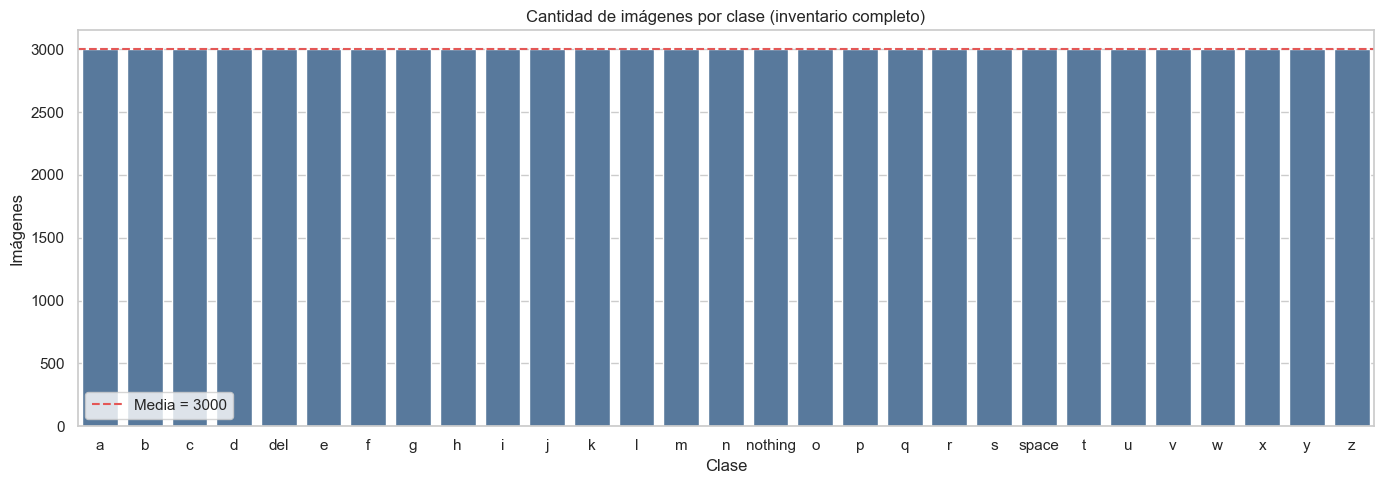

Interpretación: barras de altura similar indican que la exactitud global no estará dominada
por una clase mayoritaria. Si hubiera diferencias grandes, convendría usar métricas por clase.


In [4]:
fig, ax = plt.subplots(figsize=(14, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, color='#4C78A8', ax=ax)
ax.axhline(class_counts.mean(), color='#E45756', linestyle='--', label=f'Media = {class_counts.mean():.0f}')
ax.set(title='Cantidad de imágenes por clase (inventario completo)', xlabel='Clase', ylabel='Imágenes')
ax.legend()
plt.tight_layout(); plt.show()

print('Interpretación: barras de altura similar indican que la exactitud global no estará dominada')
print('por una clase mayoritaria. Si hubiera diferencias grandes, convendría usar métricas por clase.')

## 3. Submuestra para análisis de píxeles

Se toman hasta **600 imágenes por clase**, sin reemplazo y con semilla 42. En el dataset estándar esto produce 17,400 fotografías (20% del entrenamiento). Es un compromiso dentro del rango sugerido: conserva el mismo número de observaciones por clase y reduce de forma importante la lectura, memoria y tiempo. Los conteos anteriores no se aproximaron: corresponden a todos los archivos.

In [5]:
sample_indices = np.concatenate([
    group.sample(n=min(SAMPLE_PER_CLASS, len(group)), random_state=SEED).index.to_numpy()
    for _, group in files_df.groupby('class', sort=True)
])
sample_df = files_df.loc[sample_indices].reset_index(drop=True)
display(sample_df.groupby('class').size().rename('sample_n').to_frame().T)
print(f'Muestra: {len(sample_df):,} de {len(files_df):,} imágenes ({len(sample_df)/len(files_df):.1%}).')
print('La estratificación evita que una clase quede subrepresentada en los análisis visuales.')

class,a,b,c,d,del,e,f,g,h,i,...,r,s,space,t,u,v,w,x,y,z
sample_n,600,600,600,600,600,600,600,600,600,600,...,600,600,600,600,600,600,600,600,600,600


Muestra: 17,400 de 87,000 imágenes (20.0%).
La estratificación evita que una clase quede subrepresentada en los análisis visuales.


## 4. ¿Qué muestran las imágenes? Ejemplos de las 29 clases

Una imagen aleatoria por clase permite verificar visualmente la correspondencia etiqueta–gesto, el encuadre, el fondo y la iluminación. `nothing` representa ausencia de una seña, `space` y `del` son comandos; no son letras.

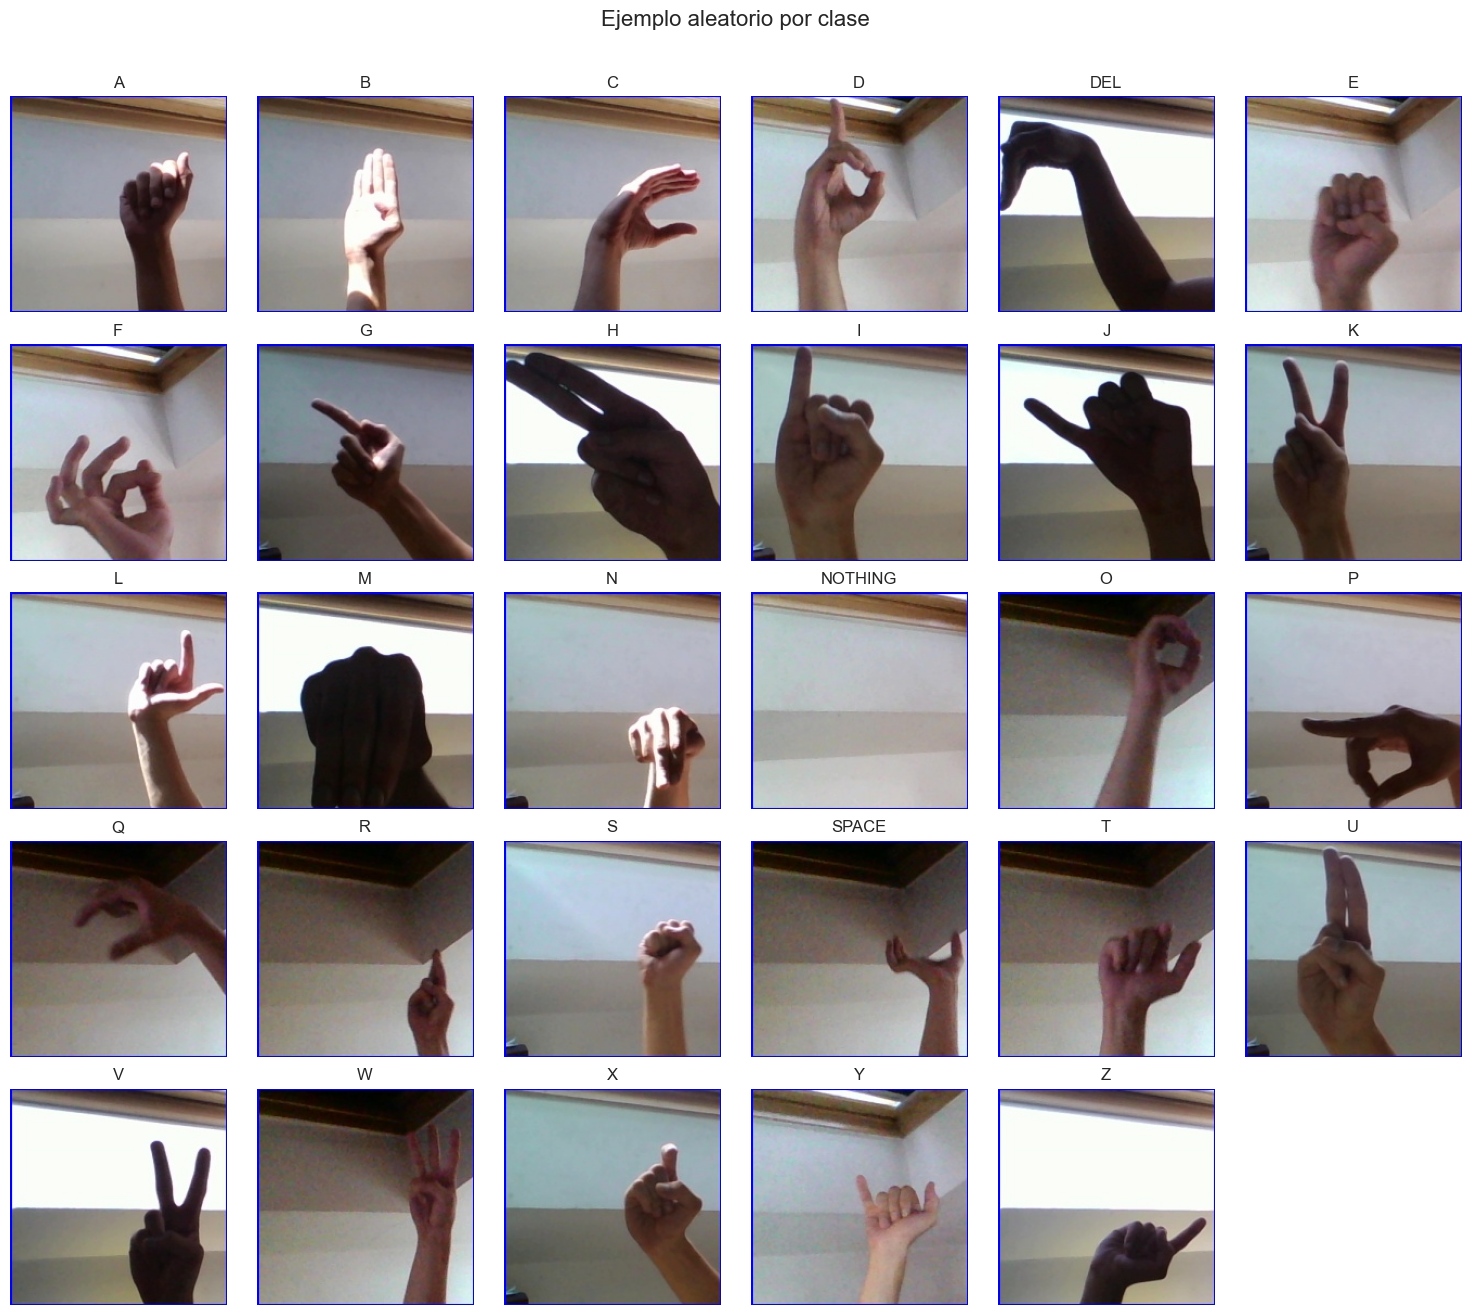

Interpretación: observe si la mano ocupa una región consistente, si el fondo es similar y
si hay clases con siluetas cercanas. Estas regularidades pueden ser atajos visuales para un modelo.


In [6]:
classes = sorted(sample_df['class'].unique())
examples = sample_df.groupby('class', group_keys=False).sample(1, random_state=SEED)
fig, axes = plt.subplots(5, 6, figsize=(15, 13))
for ax in axes.flat:
    ax.axis('off')
for ax, (_, row) in zip(axes.flat, examples.sort_values('class').iterrows()):
    with Image.open(row['path']) as img:
        ax.imshow(img.convert('RGB'))
    ax.set_title(row['class'].upper())
    ax.axis('off')
fig.suptitle('Ejemplo aleatorio por clase', y=1.01, fontsize=16)
plt.tight_layout(); plt.show()

print('Interpretación: observe si la mano ocupa una región consistente, si el fondo es similar y')
print('si hay clases con siluetas cercanas. Estas regularidades pueden ser atajos visuales para un modelo.')

### La imagen como arreglo numérico y canales RGB

Una fotografía a color es un tensor de alto × ancho × 3. Cada canal contiene intensidades entre 0 y 255. Esta inspección conecta el contenido visual con las variables numéricas usadas después y permite confirmar que los colores se codifican correctamente.

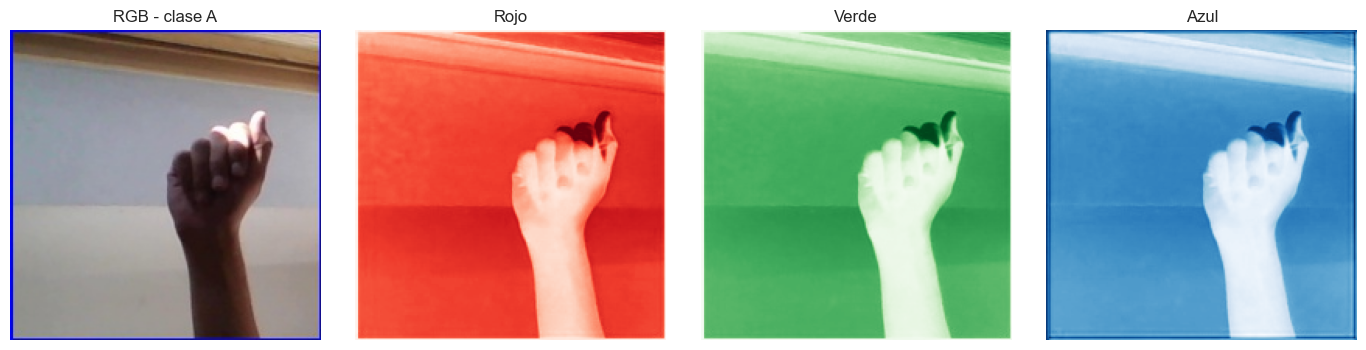

**Recorte numérico 8×8 del canal rojo en el centro de la imagen:**

,0,1,2,3,4,5,6,7
0,162,162,164,166,160,97,87,88
1,160,161,163,166,163,103,87,88
2,160,162,162,167,166,112,91,92
3,161,162,162,165,166,115,94,96
4,162,163,162,163,163,112,95,97
5,161,161,162,164,164,106,95,95
6,161,160,162,164,164,99,98,95
7,162,159,160,162,162,94,99,94


Forma del tensor: (200, 200, 3); tipo: uint8; rango: [0, 255].
Interpretación: los tres canales contienen información de iluminación, piel y fondo;
por eso se analizarán sus medias, pero la forma espacial de la mano sigue siendo esencial.


In [7]:
example_row = examples.sort_values('class').iloc[0]
with Image.open(example_row['path']) as img:
    example_rgb = np.asarray(img.convert('RGB'), dtype=np.uint8)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
axes[0].imshow(example_rgb)
axes[0].set_title(f"RGB - clase {example_row['class'].upper()}")
for channel, (name, cmap) in enumerate([('Rojo', 'Reds'), ('Verde', 'Greens'), ('Azul', 'Blues')]):
    axes[channel + 1].imshow(example_rgb[..., channel], cmap=cmap, vmin=0, vmax=255)
    axes[channel + 1].set_title(name)
for ax in axes:
    ax.axis('off')
plt.tight_layout(); plt.show()

center_y, center_x = example_rgb.shape[0] // 2, example_rgb.shape[1] // 2
red_patch = example_rgb[center_y-4:center_y+4, center_x-4:center_x+4, 0]
display(Markdown('**Recorte numérico 8×8 del canal rojo en el centro de la imagen:**'))
display(pd.DataFrame(red_patch))
print(f'Forma del tensor: {example_rgb.shape}; tipo: {example_rgb.dtype}; rango: [{example_rgb.min()}, {example_rgb.max()}].')
print('Interpretación: los tres canales contienen información de iluminación, piel y fondo;')
print('por eso se analizarán sus medias, pero la forma espacial de la mano sigue siendo esencial.')

### Variabilidad dentro de una misma clase

El siguiente cruce **clase × ejemplos** muestra ocho fotografías de clases visualmente cercanas. Permite observar cambios de posición, rotación, escala, iluminación y fondo dentro de la misma etiqueta, además de diferencias pequeñas entre gestos.

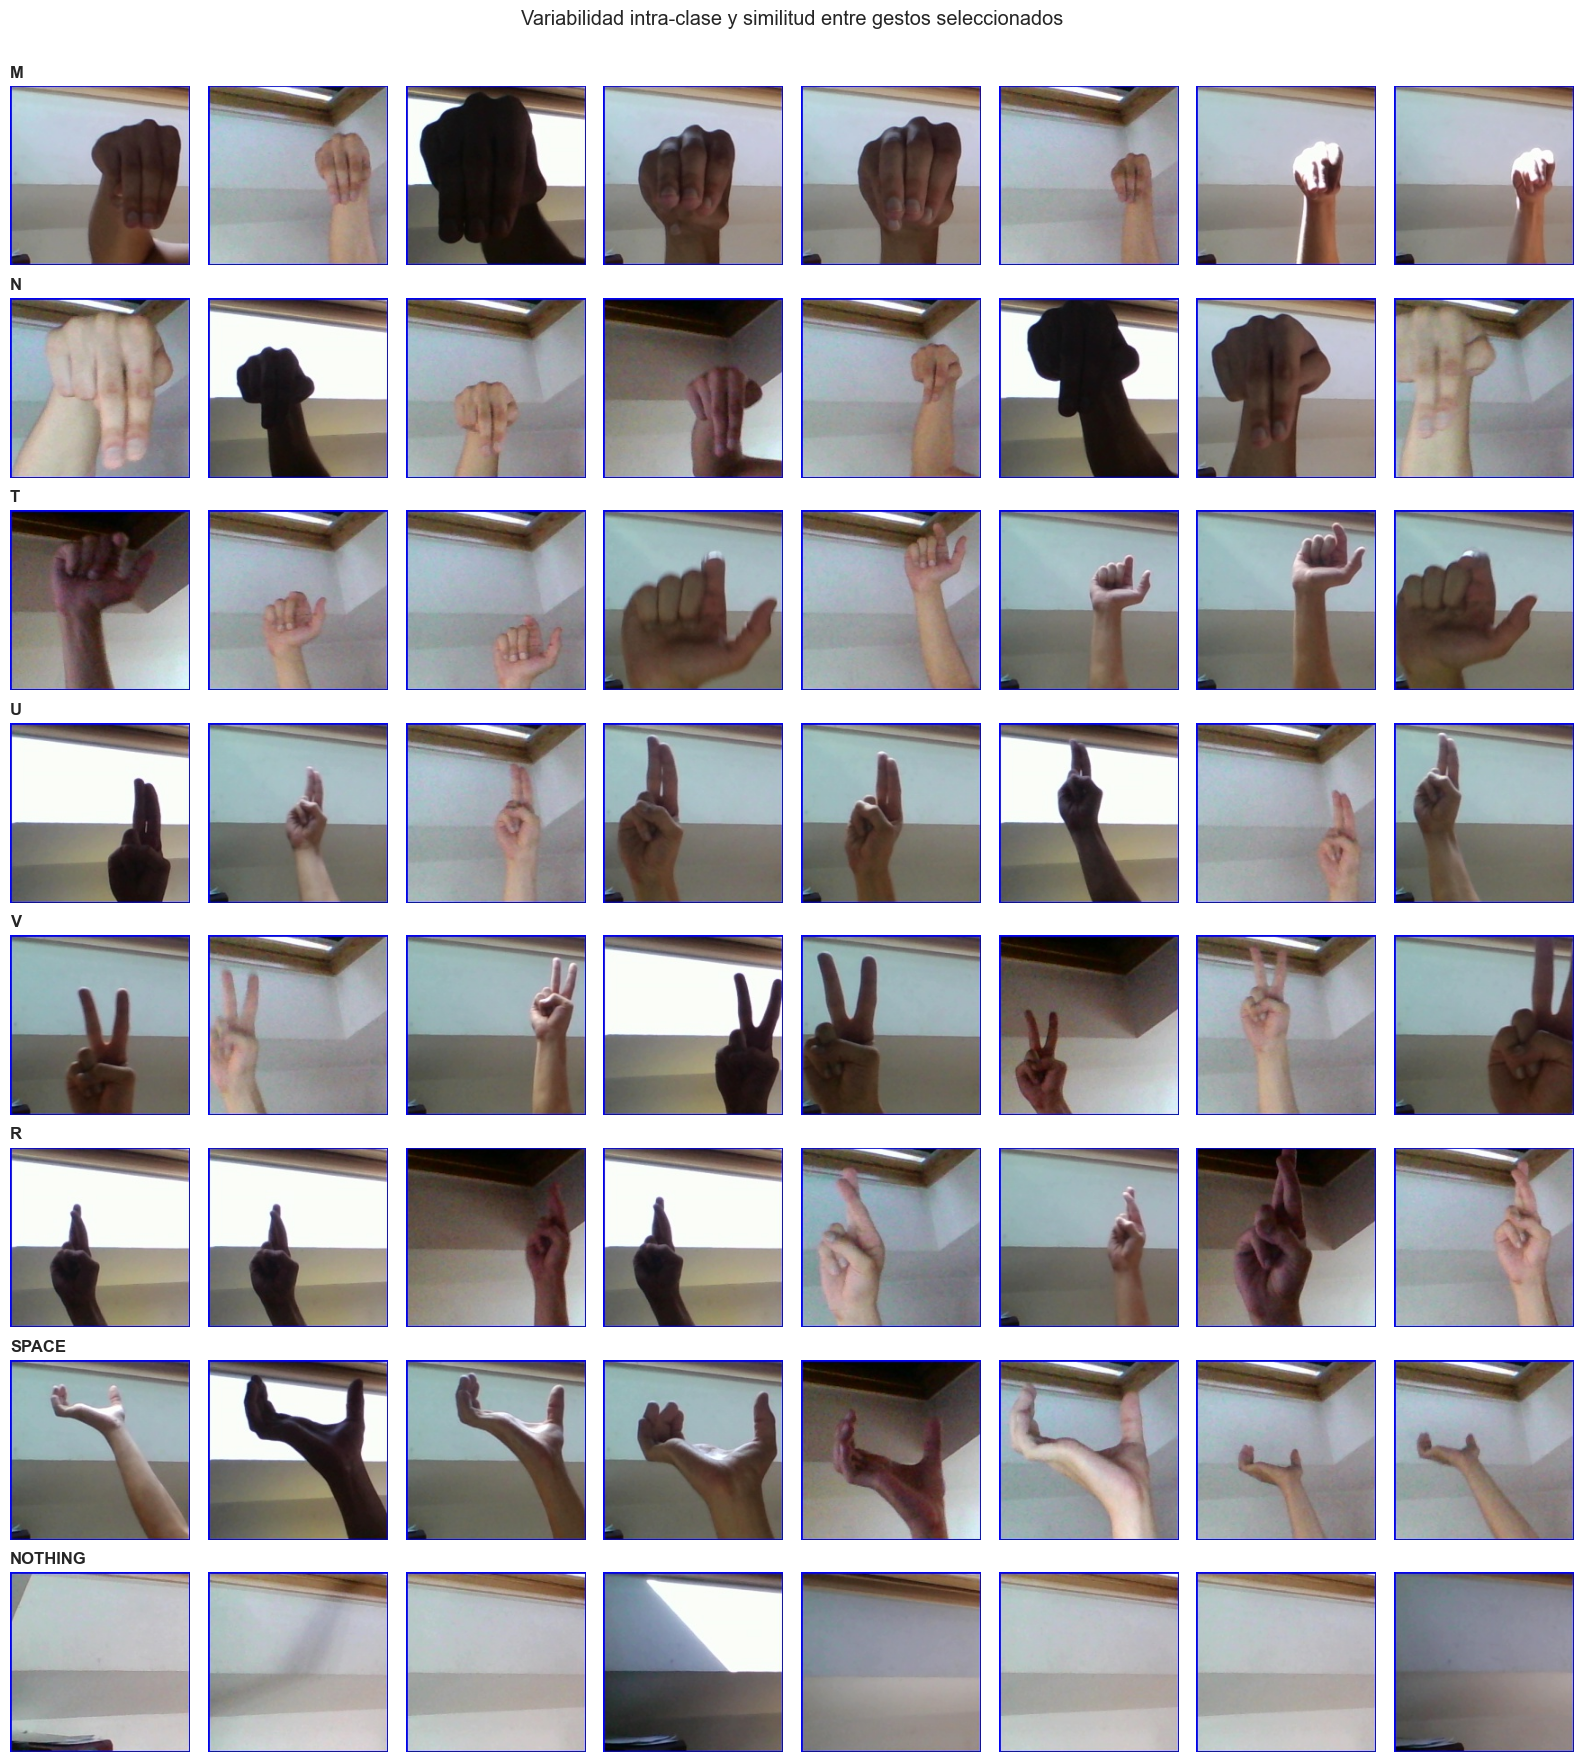

Interpretación: una clase es difícil si cambia mucho entre columnas; dos clases son difíciles de
separar si sus diferencias se concentran en pocos dedos. Esto motiva aumentos moderados y métricas por clase.


In [8]:
focus_classes = [c for c in ['m', 'n', 't', 'u', 'v', 'r', 'space', 'nothing'] if c in classes]
n_examples = 8
fig, axes = plt.subplots(len(focus_classes), n_examples, figsize=(16, 2.2 * len(focus_classes)), squeeze=False)
for i, label in enumerate(focus_classes):
    chosen = sample_df[sample_df['class'] == label].sample(n_examples, random_state=SEED + i)
    for j, (_, row) in enumerate(chosen.iterrows()):
        with Image.open(row['path']) as img:
            axes[i, j].imshow(img.convert('RGB'))
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_title(label.upper(), loc='left', fontweight='bold')
plt.suptitle('Variabilidad intra-clase y similitud entre gestos seleccionados', y=1.002)
plt.tight_layout(); plt.show()

print('Interpretación: una clase es difícil si cambia mucho entre columnas; dos clases son difíciles de')
print('separar si sus diferencias se concentran en pocos dedos. Esto motiva aumentos moderados y métricas por clase.')

## 5. ¿Hay problemas de formato, dimensiones o calidad?

Se decodifica cada imagen de la submuestra y se calculan variables derivadas: dimensiones, modo de color, brillo promedio, contraste (desviación estándar del gris), medias RGB y nitidez aproximada mediante diferencias entre píxeles vecinos. Estas variables convierten contenido visual en cantidades que pueden cruzarse con la clase. También se construye una versión gris 32×32 únicamente para medir similitud y variabilidad.

In [9]:
def image_features(path):
    with Image.open(path) as original:
        width, height = original.size
        file_format, mode = original.format, original.mode
        rgb = np.asarray(original.convert('RGB').resize(EDA_SIZE, Image.Resampling.BILINEAR), dtype=np.float32)
    gray = rgb @ np.array([0.299, 0.587, 0.114], dtype=np.float32)
    dx, dy = np.diff(gray, axis=1), np.diff(gray, axis=0)
    gray32 = np.asarray(Image.fromarray(gray.astype(np.uint8)).resize((32, 32), Image.Resampling.BILINEAR), dtype=np.float32)
    return {
        'width': width, 'height': height, 'mode': mode, 'format': file_format,
        'brightness': float(gray.mean()), 'contrast': float(gray.std()),
        'red_mean': float(rgb[..., 0].mean()), 'green_mean': float(rgb[..., 1].mean()),
        'blue_mean': float(rgb[..., 2].mean()),
        'sharpness': float((np.mean(dx**2) + np.mean(dy**2)) / 2),
        'gray32': gray32.ravel()
    }

feature_rows, bad_files = [], []
for row in tqdm(sample_df.itertuples(index=False), total=len(sample_df), desc='Extrayendo características'):
    try:
        values = image_features(row.path)
        gray32 = values.pop('gray32')
        feature_rows.append({'path': row.path, 'class': row[1], **values, 'gray32': gray32})
    except Exception as exc:
        bad_files.append({'path': str(row.path), 'error': repr(exc)})

features_df = pd.DataFrame(feature_rows)
print(f'Procesadas: {len(features_df):,} | no legibles: {len(bad_files):,}')
display(pd.DataFrame(bad_files).head() if bad_files else Markdown('**No se detectaron archivos dañados en la submuestra.**'))

Extrayendo características:   0%|          | 0/17400 [00:00<?, ?it/s]

Procesadas: 17,400 | no legibles: 0


**No se detectaron archivos dañados en la submuestra.**

In [10]:
format_table = (features_df.groupby(['width', 'height', 'mode', 'format'])
                .size().rename('n').reset_index().sort_values('n', ascending=False))
display(format_table)
standard_pct = 100 * ((features_df['width'] == 200) & (features_df['height'] == 200) &
                      (features_df['mode'] == 'RGB')).mean()
display(Markdown(
    f'**Hallazgo.** El **{standard_pct:.2f}%** de la submuestra cumple simultáneamente 200×200 y RGB. '
    f'Se encontraron **{len(bad_files)}** archivos no legibles. Cualquier excepción debe revisarse '
    'antes de crear un pipeline, pues los lotes de una red requieren dimensiones homogéneas.'
))

,width,height,mode,format,n
0,200,200,RGB,JPEG,17400


**Hallazgo.** El **100.00%** de la submuestra cumple simultáneamente 200×200 y RGB. Se encontraron **0** archivos no legibles. Cualquier excepción debe revisarse antes de crear un pipeline, pues los lotes de una red requieren dimensiones homogéneas.

## 6. Cruces de variables: clase × brillo, contraste, color y nitidez

Los diagramas de caja muestran mediana, dispersión y valores extremos por etiqueta. Si una clase tiene una distribución de iluminación o nitidez distinta, existe riesgo de que un futuro clasificador aprenda condiciones de captura en vez de la forma de la mano. La variabilidad es señal útil para decidir normalización y aumentos de datos.

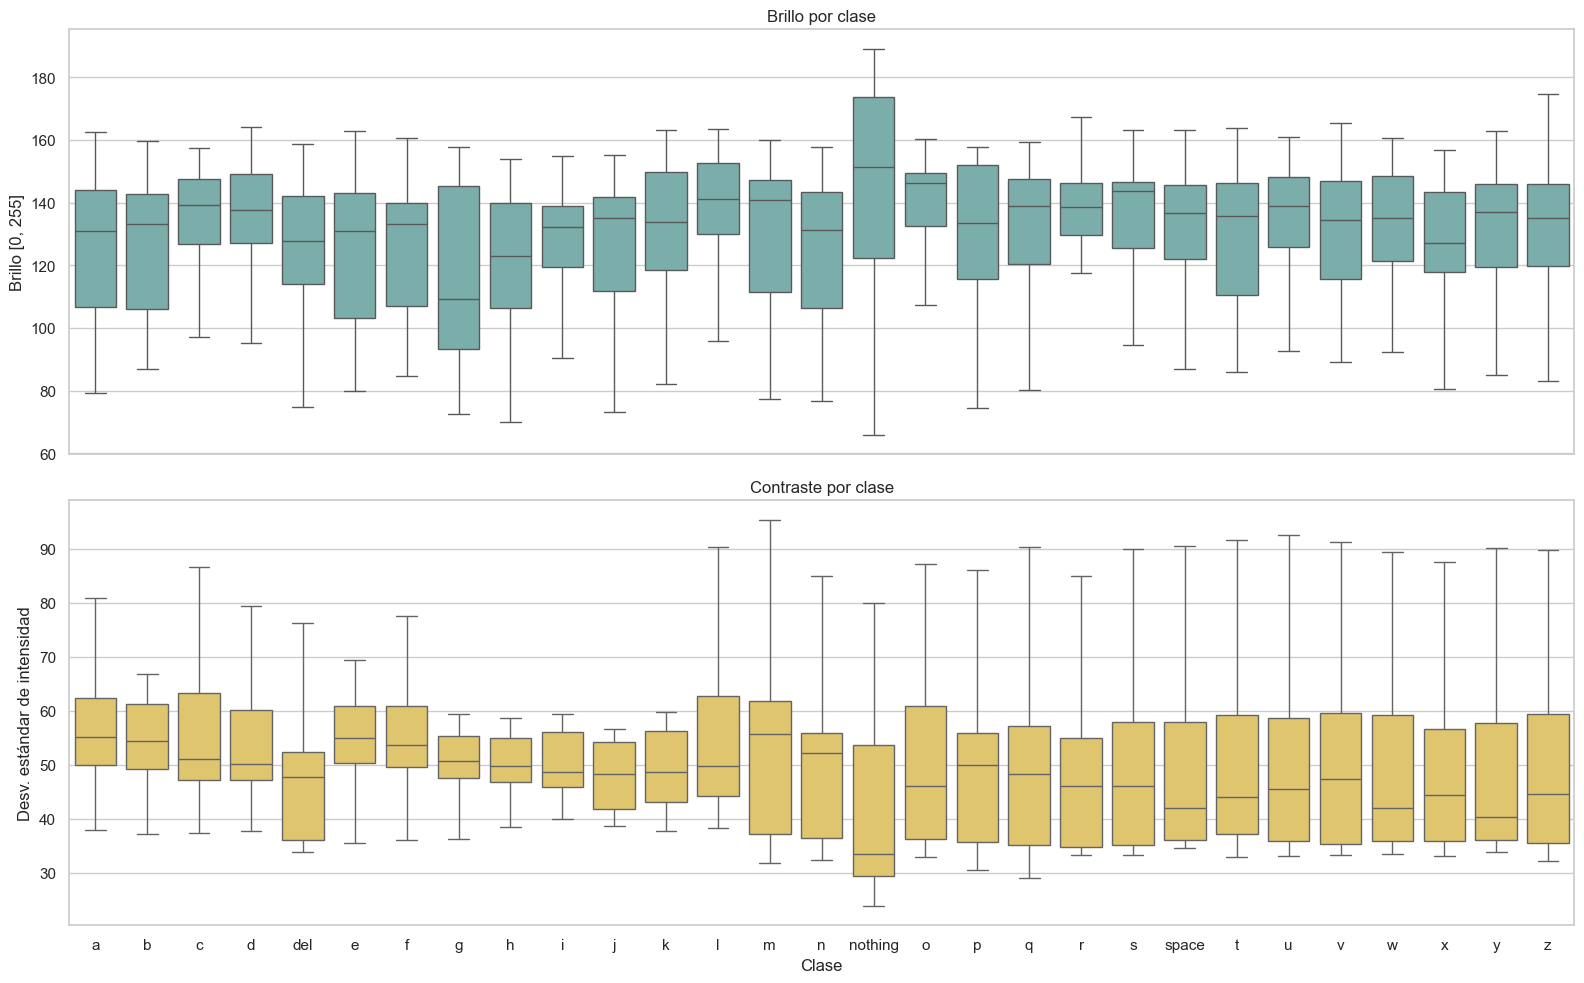

brightness        contrast        sharpness        
              mean    std     mean    std      mean     std
class                                                      
a           126.25  21.19    58.74  13.10    260.18  100.90
b           127.85  20.14    58.11  14.35    267.26  107.89
c           134.65  16.08    56.95  13.60    297.47  113.78
d           134.85  18.02    55.82  13.76    284.19  111.04
del         123.99  20.46    49.96  15.71    229.54  132.56
e           126.95  21.34    58.31  13.74    270.86   98.90
f           124.81  20.26    56.84  12.04    341.22  149.62
g           117.46  26.56    54.30  15.10    233.14  119.76
h           121.45  21.41    54.83  13.98    229.32  119.83
i           126.28  18.63    55.23  15.12    238.20  123.57
j           126.23  21.58    52.77  15.10    232.53  124.95
k           131.28  22.53    53.60  14.57    253.13  128.88
l           137.05  19.68    56.04  14.60    277.04   98.30
m           130.69  20.30    54.13  17.54    238.88   98.16
n           125.69  22.44    51.84  16.78    241.06  100.60
nothing     144.91  29.36    41.40  16.80    124.35   65.77
o           138.48  16.76    50.97  16.31    245.19  108.19
p           130.15  23.32    50.67  16.18    246.70  115.10
q           131.20  21.39    50.04  15.48    239.42  139.13
r           132.30  21.28    49.37  16.18    203.24   96.83
s           134.48  18.64    50.12  17.04    208.82   91.54
space       131.13  18.66    49.40  17.07    224.31  122.49
t           129.56  19.94    51.20  18.12    222.93  117.94
u           133.96  18.48    50.04  16.81    205.94   91.22
v           130.16  19.72    50.42  16.60    227.28  120.81
w           131.41  18.66    49.03  16.72    239.83  149.32
x           126.48  19.96    50.40  18.47    203.19  103.94
y           131.45  20.09    49.12  17.64    224.46  126.11
z           130.76  20.33    49.92  16.79    222.15  116.30

Hallazgo cuantitativo: las medias por clase abarcan 27.5 niveles de brillo y
17.3 puntos de contraste. Rangos grandes sugieren condiciones de captura asociadas a la etiqueta.


In [11]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
sns.boxplot(data=features_df, x='class', y='brightness', showfliers=False, color='#72B7B2', ax=axes[0])
sns.boxplot(data=features_df, x='class', y='contrast', showfliers=False, color='#F2CF5B', ax=axes[1])
axes[0].set(title='Brillo por clase', xlabel='', ylabel='Brillo [0, 255]')
axes[1].set(title='Contraste por clase', xlabel='Clase', ylabel='Desv. estándar de intensidad')
plt.tight_layout(); plt.show()

class_stats = features_df.groupby('class')[['brightness', 'contrast', 'sharpness']].agg(['mean', 'std']).round(2)
display(class_stats)
bright_range = features_df.groupby('class')['brightness'].mean().agg(lambda s: s.max() - s.min())
contrast_range = features_df.groupby('class')['contrast'].mean().agg(lambda s: s.max() - s.min())
print(f'Hallazgo cuantitativo: las medias por clase abarcan {bright_range:.1f} niveles de brillo y')
print(f'{contrast_range:.1f} puntos de contraste. Rangos grandes sugieren condiciones de captura asociadas a la etiqueta.')

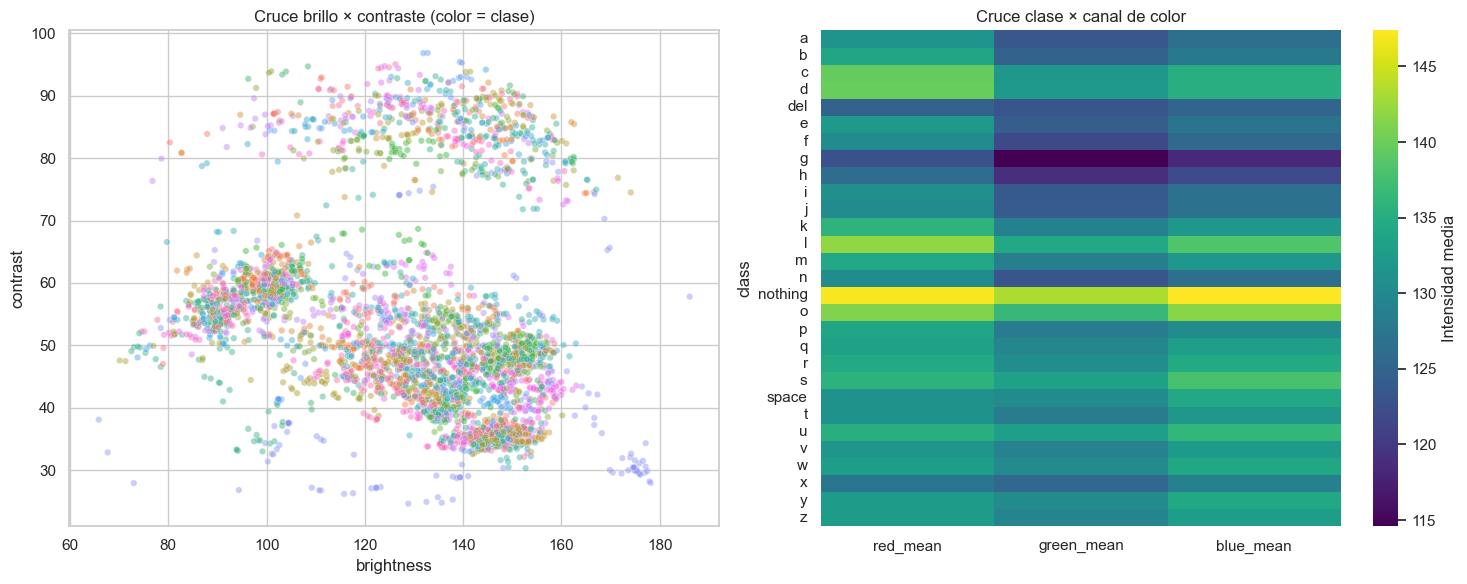

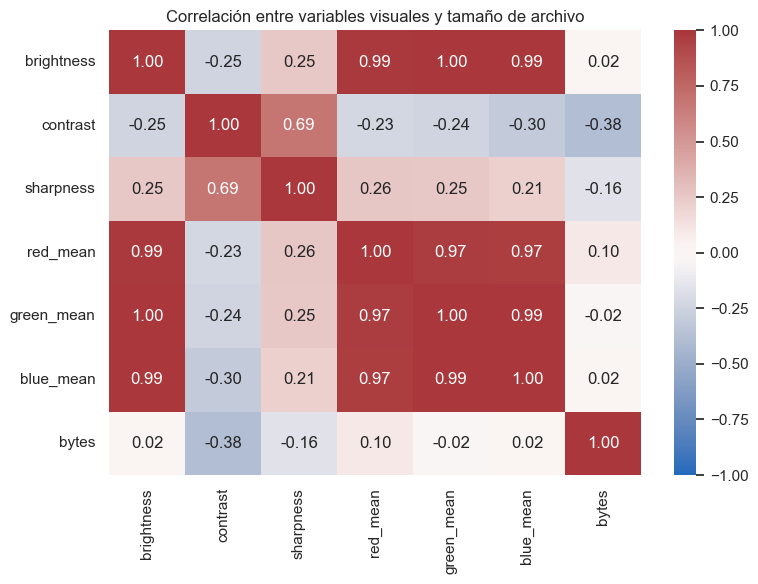

Interpretación: el solapamiento de colores en el dispersograma indica que brillo y contraste
por sí solos no deberían separar las letras. Correlaciones RGB altas son esperables por iluminación compartida.


In [12]:
plot_df = features_df.sample(min(4000, len(features_df)), random_state=SEED)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.scatterplot(data=plot_df, x='brightness', y='contrast', hue='class', palette='husl',
                s=22, alpha=.45, legend=False, ax=axes[0])
axes[0].set_title('Cruce brillo × contraste (color = clase)')
color_means = features_df.groupby('class')[['red_mean', 'green_mean', 'blue_mean']].mean()
sns.heatmap(color_means, cmap='viridis', ax=axes[1], cbar_kws={'label': 'Intensidad media'})
axes[1].set_title('Cruce clase × canal de color')
plt.tight_layout(); plt.show()

numeric_cols = ['brightness', 'contrast', 'sharpness', 'red_mean', 'green_mean', 'blue_mean', 'bytes']
corr_df = features_df.merge(sample_df[['path', 'bytes']], on='path', how='left')[numeric_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='vlag', center=0, vmin=-1, vmax=1)
plt.title('Correlación entre variables visuales y tamaño de archivo')
plt.tight_layout(); plt.show()
print('Interpretación: el solapamiento de colores en el dispersograma indica que brillo y contraste')
print('por sí solos no deberían separar las letras. Correlaciones RGB altas son esperables por iluminación compartida.')

## 7. ¿Cuánta variabilidad hay dentro de cada clase?

Para cada etiqueta se calcula una imagen gris promedio de 32×32. La distancia absoluta de cada fotografía a ese promedio es una medida sencilla de variabilidad intra-clase: valores altos indican cambios mayores de encuadre, mano, fondo o iluminación. No es una métrica perceptual perfecta, pero sirve como diagnóstico comparativo.

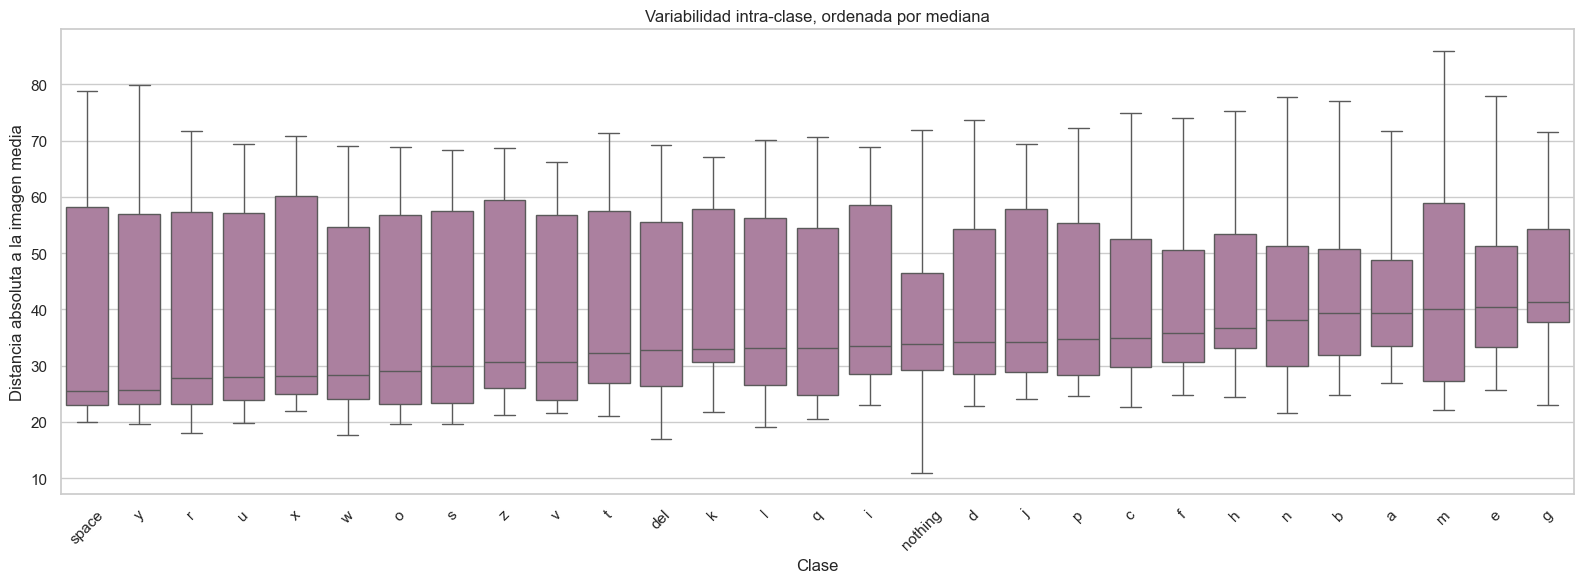

Clases con mayor variabilidad según esta medida:


,mediana_distancia
class,
g,41.369999
e,40.450001
m,40.130001
a,39.380001
b,39.279999


Estas clases merecen inspección manual; la causa puede ser variación genuina o imágenes atípicas.


In [13]:
mean_images = {}
distance_rows = []
for label, group in features_df.groupby('class'):
    stack = np.stack(group['gray32'].to_numpy())
    mean_img = stack.mean(axis=0)
    mean_images[label] = mean_img
    distances = np.mean(np.abs(stack - mean_img), axis=1)
    distance_rows.extend({'class': label, 'distance_to_class_mean': value} for value in distances)
distance_df = pd.DataFrame(distance_rows)

fig, ax = plt.subplots(figsize=(16, 6))
order = distance_df.groupby('class')['distance_to_class_mean'].median().sort_values().index
sns.boxplot(data=distance_df, x='class', y='distance_to_class_mean', order=order,
            showfliers=False, color='#B279A2', ax=ax)
ax.set(title='Variabilidad intra-clase, ordenada por mediana', xlabel='Clase',
       ylabel='Distancia absoluta a la imagen media')
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

variability = distance_df.groupby('class')['distance_to_class_mean'].median().sort_values(ascending=False)
print('Clases con mayor variabilidad según esta medida:')
display(variability.head(5).round(2).to_frame('mediana_distancia'))
print('Estas clases merecen inspección manual; la causa puede ser variación genuina o imágenes atípicas.')

### Imágenes promedio por clase

Al promediar fotografías píxel a píxel, los elementos consistentes permanecen y los que cambian se vuelven borrosos. Si la silueta de una seña sobrevive al promedio, existe una estructura espacial común dentro de esa clase; un fondo muy definido, en cambio, revelaría un posible atajo del dataset.

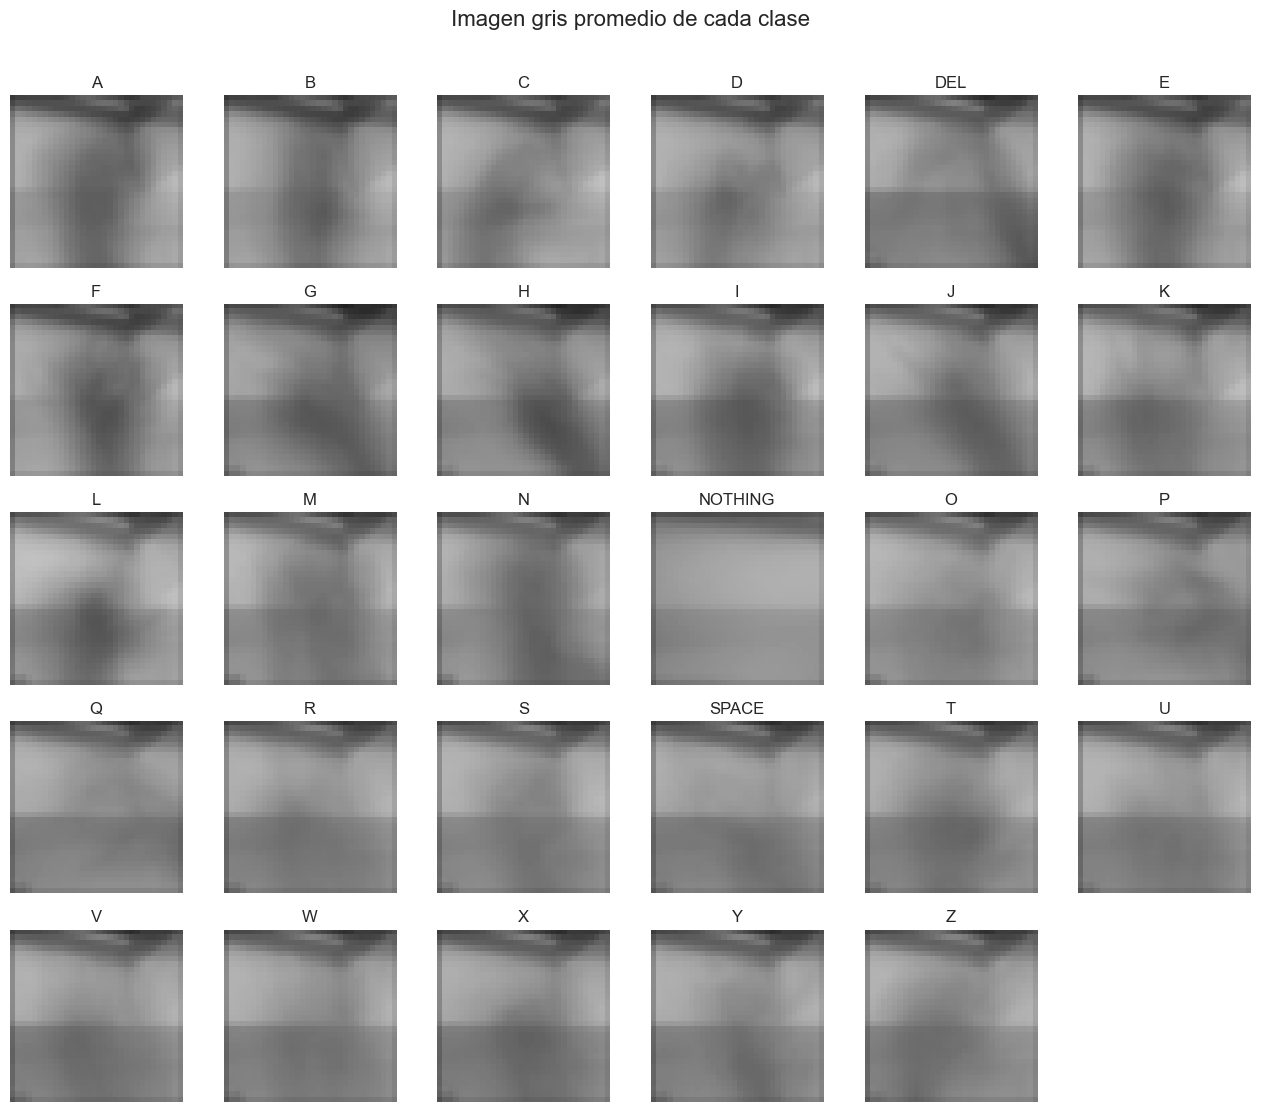

Interpretación: regiones nítidas representan posiciones consistentes; regiones borrosas reflejan
variación de postura o encuadre. Fondos promedio similares sugieren un protocolo de captura común.


In [14]:
fig, axes = plt.subplots(5, 6, figsize=(13, 11))
for ax in axes.flat:
    ax.axis('off')
for ax, label in zip(axes.flat, sorted(mean_images)):
    ax.imshow(mean_images[label].reshape(32, 32), cmap='gray', vmin=0, vmax=255)
    ax.set_title(label.upper())
    ax.axis('off')
fig.suptitle('Imagen gris promedio de cada clase', y=1.01, fontsize=16)
plt.tight_layout(); plt.show()

print('Interpretación: regiones nítidas representan posiciones consistentes; regiones borrosas reflejan')
print('variación de postura o encuadre. Fondos promedio similares sugieren un protocolo de captura común.')

## 8. ¿Qué clases podrían confundirse visualmente?

Se compara la imagen promedio de cada clase usando similitud coseno. Valores altos señalan apariencia global parecida, aunque el fondo compartido también eleva la similitud; por eso este resultado genera hipótesis y no demuestra confusión de un modelo.

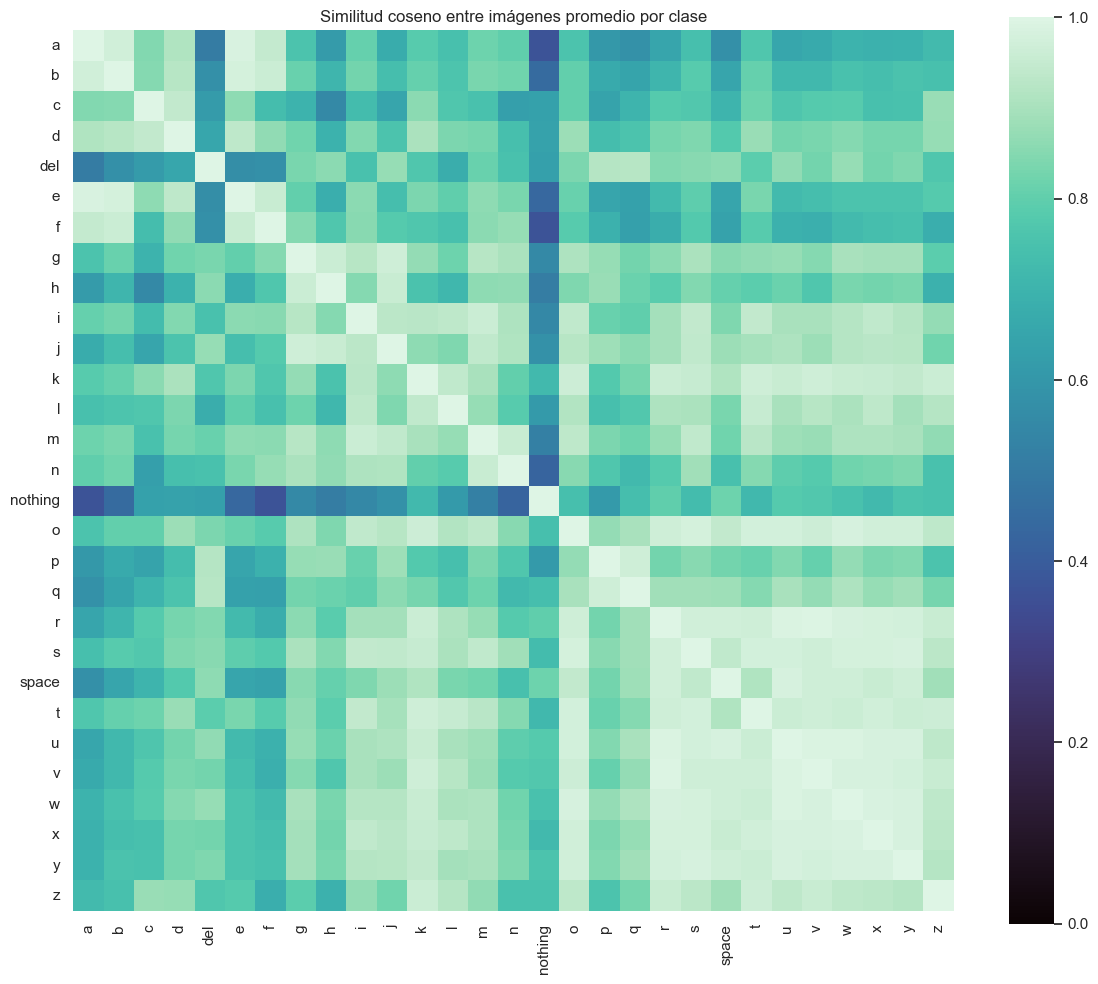

,class_1,class_2,similarity
365,r,v,0.994
364,r,u,0.992
392,u,w,0.992
391,u,v,0.992
4,a,e,0.986
400,w,x,0.985
376,s,y,0.984
393,u,x,0.983
394,u,y,0.983
396,v,w,0.983


Hallazgo: estos pares son candidatos prioritarios para revisar después mediante una matriz de confusión,
pero la similitud promedio puede deberse tanto al gesto como a fondos y posiciones compartidos.


In [15]:
labels = sorted(mean_images)
M = np.stack([mean_images[label] for label in labels])
M_centered = M - M.mean(axis=1, keepdims=True)
norms = np.linalg.norm(M_centered, axis=1, keepdims=True) + 1e-9
similarity = (M_centered / norms) @ (M_centered / norms).T
sim_df = pd.DataFrame(similarity, index=labels, columns=labels)

plt.figure(figsize=(12, 10))
sns.heatmap(sim_df, cmap='mako', vmin=0, vmax=1, square=True)
plt.title('Similitud coseno entre imágenes promedio por clase')
plt.tight_layout(); plt.show()

pairs = []
for i in range(len(labels)):
    for j in range(i + 1, len(labels)):
        pairs.append((labels[i], labels[j], similarity[i, j]))
top_pairs = pd.DataFrame(pairs, columns=['class_1', 'class_2', 'similarity']).nlargest(10, 'similarity')
display(top_pairs.round(3))
print('Hallazgo: estos pares son candidatos prioritarios para revisar después mediante una matriz de confusión,')
print('pero la similitud promedio puede deberse tanto al gesto como a fondos y posiciones compartidos.')

## 9. Impacto de reducir la resolución a 64×64

La reducción propuesta mantiene color RGB y baja el número de valores por imagen de 120,000 a 12,288. Se muestran los mismos ejemplos en ambas resoluciones para comprobar si aún son distinguibles los dedos y la silueta. Esta inspección es necesaria: el ahorro no justifica perder el detalle que separa clases cercanas.

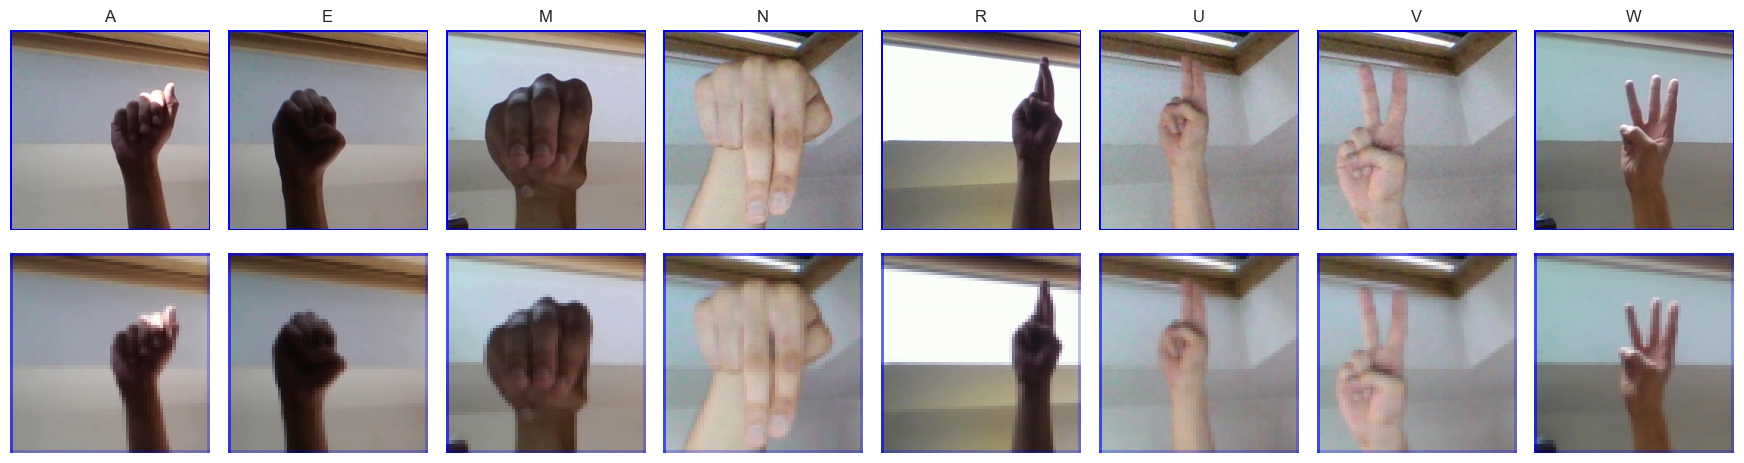

**Resultado.** 64×64 reduce **89.8%** los valores por imagen. El dataset completo a 200×200 RGB ocuparía aproximadamente **9.72 GiB** sin compresión en memoria, mientras esta submuestra a 64×64 requeriría **0.20 GiB** como `uint8` (sin contar estructuras auxiliares). La figura permite verificar el costo visual.

In [16]:
comparison_classes = [c for c in ['a', 'e', 'm', 'n', 'r', 'u', 'v', 'w'] if c in classes]
comparison = sample_df[sample_df['class'].isin(comparison_classes)].groupby('class').sample(1, random_state=SEED)
fig, axes = plt.subplots(2, len(comparison), figsize=(2.2 * len(comparison), 5), squeeze=False)
for j, (_, row) in enumerate(comparison.sort_values('class').iterrows()):
    with Image.open(row['path']) as img:
        rgb = img.convert('RGB')
        reduced = rgb.resize(EDA_SIZE, Image.Resampling.BILINEAR)
    axes[0, j].imshow(rgb); axes[1, j].imshow(reduced)
    axes[0, j].set_title(row['class'].upper())
    axes[0, j].axis('off'); axes[1, j].axis('off')
axes[0, 0].set_ylabel('200×200'); axes[1, 0].set_ylabel('64×64')
plt.tight_layout(); plt.show()

original_values = 200 * 200 * 3
reduced_values = 64 * 64 * 3
saving = 1 - reduced_values / original_values
full_raw_gb = len(files_df) * original_values / 1024**3
sample_raw_gb = len(sample_df) * reduced_values / 1024**3
display(Markdown(
    f'**Resultado.** 64×64 reduce **{saving:.1%}** los valores por imagen. '
    f'El dataset completo a 200×200 RGB ocuparía aproximadamente **{full_raw_gb:.2f} GiB** '
    f'sin compresión en memoria, mientras esta submuestra a 64×64 requeriría **{sample_raw_gb:.2f} GiB** '
    'como `uint8` (sin contar estructuras auxiliares). La figura permite verificar el costo visual.'
))

## 10. Imágenes extremas: control visual de calidad

Los valores extremos pueden ser casos reales difíciles o problemas de captura. Se muestran las imágenes con menor/mayor brillo, contraste y nitidez; no deben eliminarse automáticamente sin inspección, porque hacerlo puede reducir la capacidad de generalización.

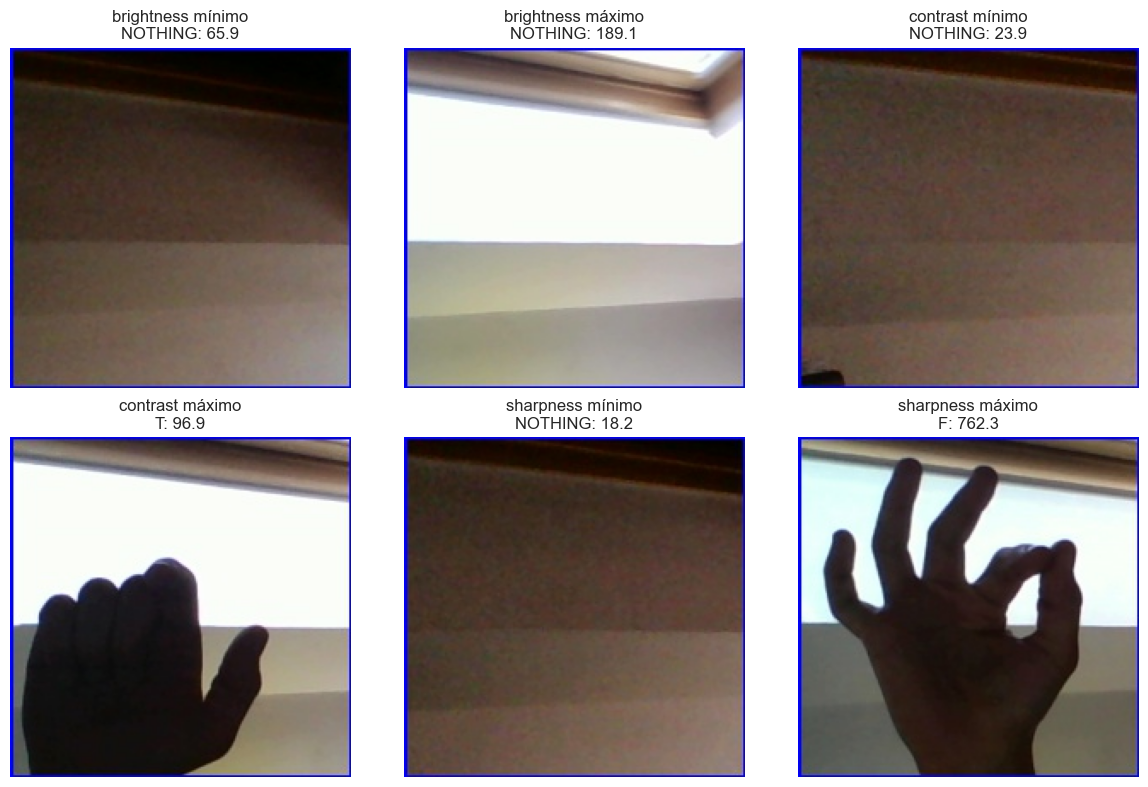

Interpretación: revise si los extremos todavía contienen una mano y una etiqueta plausible.
Conservar extremos válidos es importante para que el sistema funcione fuera de condiciones ideales.


In [17]:
extremes = []
for metric in ['brightness', 'contrast', 'sharpness']:
    for side, idx in [('mínimo', features_df[metric].idxmin()), ('máximo', features_df[metric].idxmax())]:
        row = features_df.loc[idx]
        extremes.append((metric, side, row))
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, (metric, side, row) in zip(axes.flat, extremes):
    with Image.open(row['path']) as img:
        ax.imshow(img.convert('RGB'))
    ax.set_title('{} {}\n{}: {:.1f}'.format(metric, side, row['class'].upper(), row[metric]))
    ax.axis('off')
plt.tight_layout(); plt.show()
print('Interpretación: revise si los extremos todavía contienen una mano y una etiqueta plausible.')
print('Conservar extremos válidos es importante para que el sistema funcione fuera de condiciones ideales.')

## 11. Conclusiones y consecuencias para etapas posteriores

La siguiente celda genera un resumen con resultados calculados, de modo que el informe no dependa de cifras escritas antes de ejecutar el análisis.

In [18]:
most_variable = ', '.join(variability.head(3).index.str.upper())
closest_pairs = ', '.join((top_pairs['class_1'].str.upper() + '–' + top_pairs['class_2'].str.upper()).head(3))
conclusions = f'''
### Resumen de hallazgos

- **Estructura:** se inventariaron **{len(files_df):,} imágenes** en **{class_counts.size} clases**. Las 26 letras conviven con `DEL`, `NOTHING` y `SPACE`, que cumplen una función distinta y deben mantenerse como etiquetas explícitas si el producto necesita comandos en tiempo real.
- **Balance:** la razón entre la clase mayor y la menor fue **{imbalance_ratio:.3f}**. Un valor cercano a 1 indica que el conteo no introduce un desbalance sustancial; aun así, deben reportarse métricas por clase.
- **Calidad técnica:** **{standard_pct:.2f}%** de la submuestra fue RGB de 200×200 y hubo **{len(bad_files)}** archivos no legibles.
- **Variabilidad:** según la distancia a la imagen promedio, las clases más variables fueron **{most_variable}**. Conviene revisar sus ejemplos y usar aumentos realistas de iluminación, traslación y rotación en una etapa de modelado.
- **Similitud entre clases:** los pares promedio más parecidos fueron **{closest_pairs}**. Son hipótesis de confusión, no resultados de clasificación; deberán contrastarse después con precisión/recall y matriz de confusión.
- **Preprocesamiento justificado:** se analizaron hasta **{SAMPLE_PER_CLASS} imágenes por clase** con semilla {SEED}, y se propone 64×64 porque reduce **{saving:.1%}** los valores respecto de 200×200. La inspección visual anterior determina si el detalle de dedos sigue siendo suficiente.
- **Riesgo de fuga:** fotografías consecutivas del mismo contexto pueden ser casi idénticas. Una división aleatoria puede colocar capturas vecinas en entrenamiento y prueba e inflar el rendimiento. Si no existen identificadores de persona o sesión, se deben buscar secuencias/duplicados y documentar esta limitación.
- **Validez externa:** fondos, iluminación y manos poco diversas pueden hacer que el desempeño dentro del dataset no represente usuarios reales. Un conjunto de prueba propio debe incluir personas, fondos, distancias e iluminación no observados durante entrenamiento.
- **Limitación de J y Z:** en el uso real estas letras implican movimiento, mientras aquí se representan con fotografías estáticas. Un clasificador de una sola imagen no modelará la trayectoria temporal; el alcance del producto debe declararlo.

**Alcance:** este cuaderno termina en el EDA. No se entrenó, validó ni comparó ningún modelo.
'''
display(Markdown(conclusions))


### Resumen de hallazgos

- **Estructura:** se inventariaron **87,000 imágenes** en **29 clases**. Las 26 letras conviven con `DEL`, `NOTHING` y `SPACE`, que cumplen una función distinta y deben mantenerse como etiquetas explícitas si el producto necesita comandos en tiempo real.
- **Balance:** la razón entre la clase mayor y la menor fue **1.000**. Un valor cercano a 1 indica que el conteo no introduce un desbalance sustancial; aun así, deben reportarse métricas por clase.
- **Calidad técnica:** **100.00%** de la submuestra fue RGB de 200×200 y hubo **0** archivos no legibles.
- **Variabilidad:** según la distancia a la imagen promedio, las clases más variables fueron **G, E, M**. Conviene revisar sus ejemplos y usar aumentos realistas de iluminación, traslación y rotación en una etapa de modelado.
- **Similitud entre clases:** los pares promedio más parecidos fueron **R–V, R–U, U–W**. Son hipótesis de confusión, no resultados de clasificación; deberán contrastarse después con precisión/recall y matriz de confusión.
- **Preprocesamiento justificado:** se analizaron hasta **600 imágenes por clase** con semilla 42, y se propone 64×64 porque reduce **89.8%** los valores respecto de 200×200. La inspección visual anterior determina si el detalle de dedos sigue siendo suficiente.
- **Riesgo de fuga:** fotografías consecutivas del mismo contexto pueden ser casi idénticas. Una división aleatoria puede colocar capturas vecinas en entrenamiento y prueba e inflar el rendimiento. Si no existen identificadores de persona o sesión, se deben buscar secuencias/duplicados y documentar esta limitación.
- **Validez externa:** fondos, iluminación y manos poco diversas pueden hacer que el desempeño dentro del dataset no represente usuarios reales. Un conjunto de prueba propio debe incluir personas, fondos, distancias e iluminación no observados durante entrenamiento.
- **Limitación de J y Z:** en el uso real estas letras implican movimiento, mientras aquí se representan con fotografías estáticas. Un clasificador de una sola imagen no modelará la trayectoria temporal; el alcance del producto debe declararlo.

**Alcance:** este cuaderno termina en el EDA. No se entrenó, validó ni comparó ningún modelo.


## Referencia del dataset

Grassknoted. *ASL Alphabet*. Kaggle: https://www.kaggle.com/datasets/grassknoted/asl-alphabet

Para entregar el informe, ejecute **Run All**, revise visualmente los casos extremos y guarde el cuaderno con sus salidas. Las conclusiones se actualizarán con los valores observados.